c:\Users\Navanit Reddy T\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

Class balance (Label value counts):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
ju

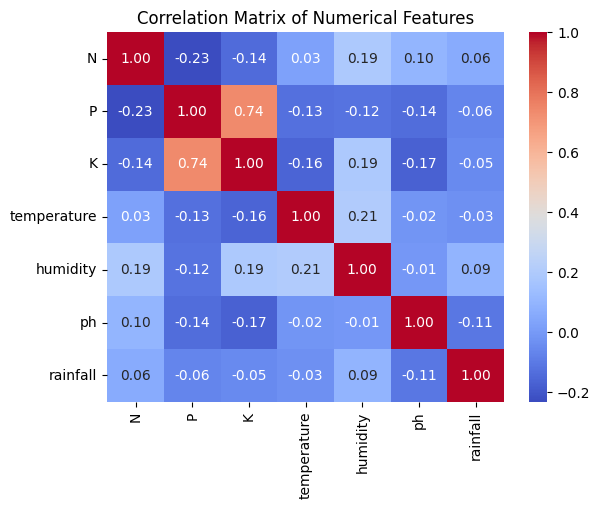

In [3]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download('atharvaingle/crop-recommendation-dataset')
csv_path = os.path.join(path, 'Crop_recommendation.csv')

# Load Data
df = pd.read_csv(csv_path)

# Display basic info
display(df.head())
df.info()
print("\nClass balance (Label value counts):")
print(df['label'].value_counts())

# Compute correlation matrix for numerical features
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Visualize correlation matrixplt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Split features and target
X = df.drop('label', axis=1)
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gaussian NB': GaussianNB()
}

# Train, predict, and evaluate
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9636
KNN Accuracy: 0.9568
SVC Accuracy: 0.9682
Random Forest Accuracy: 0.9932
Gaussian NB Accuracy: 0.9955


## Soft Voting Ensemble & Knowledge Distillation

### 1. Soft Voting Ensemble
In this notebook, we use a **Soft Voting Ensemble** to combine the predictions of multiple base classifiers (Logistic Regression, KNN, SVC, Random Forest, Gaussian NB). Instead of relying on a simple majority vote (hard voting), soft voting averages the predicted probabilities from all models for each class, and the class with the highest average probability is chosen as the final prediction.

The probability averaging formula for a given class $c$ across $N$ classifiers is:

$$ P(y=c|x) = \frac{1}{N} \sum_{i=1}^{N} P_i(y=c|x) $$

Where $P_i(y=c|x)$ is the predicted probability of class $c$ by the $i$-th classifier.

### 2. Teacher-Student Knowledge Distillation (Surrogate Model)
While the ensemble provides high accuracy, it acts as a complex "black box". To extract interpretable insights, we employ a **Teacher-Student Knowledge Distillation** approach:
- **Teacher Model**: The complex Soft Voting Ensemble generates predictions (soft or hard labels) on the training data.
- **Student Model**: A simpler, highly interpretable model (a Surrogate Decision Tree with limited depth) is trained using the features and the predictions generated by the Teacher model, rather than the original true labels.

This process distills the complex decision boundaries of the ensemble into a human-readable format, allowing us to extract actionable **'if-then' farming rules**.

## Soft Voting Ensemble & Knowledge Distillation

### 1. Soft Voting Ensemble
In this notebook, we use a **Soft Voting Ensemble** to combine the predictions of multiple base classifiers (Logistic Regression, KNN, SVC, Random Forest, Gaussian NB). Instead of relying on a simple majority vote (hard voting), soft voting averages the predicted probabilities from all models for each class, and the class with the highest average probability is chosen as the final prediction.

The probability averaging formula for a given class $c$ across $N$ classifiers is:

$$ P(y=c|x) = \frac{1}{N} \sum_{i=1}^{N} P_i(y=c|x) $$

Where $P_i(y=c|x)$ is the predicted probability of class $c$ by the $i$-th classifier.

### 2. Teacher-Student Knowledge Distillation (Surrogate Model)
While the ensemble provides high accuracy, it acts as a complex "black box". To extract interpretable insights, we employ a **Teacher-Student Knowledge Distillation** approach:
- **Teacher Model**: The complex Soft Voting Ensemble generates predictions (soft or hard labels) on the training data.
- **Student Model**: A simpler, highly interpretable model (a Surrogate Decision Tree with limited depth) is trained using the features and the predictions generated by the Teacher model, rather than the original true labels.

This process distills the complex decision boundaries of the ensemble into a human-readable format, allowing us to extract actionable **'if-then' farming rules**.

In [5]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# Instantiate the soft voting ensemble
ensemble = VotingClassifier(
    estimators=list(trained_models.items()),
    voting='soft'
)

# Train the ensemble
ensemble.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_ens = ensemble.predict(X_test_scaled)

# Evaluate performance
acc_ens = accuracy_score(y_test, y_pred_ens)
print(f"Ensemble Accuracy: {acc_ens:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_ens))


Ensemble Accuracy: 0.9886

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.

In [6]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Generate teacher labels using the ensemble on training data
y_train_teacher = ensemble.predict(X_train_scaled)

# Initialize and train the surrogate Decision Tree
surrogate_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
surrogate_tree.fit(X_train_scaled, y_train_teacher)

# Predict using the surrogate model on test data
y_pred_surrogate = surrogate_tree.predict(X_test_scaled)

# Calculate and print accuracy compared to true test labels
acc_surrogate = accuracy_score(y_test, y_pred_surrogate)
print(f"Surrogate Model Accuracy vs True Labels: {acc_surrogate:.4f}")

# Calculate and print fidelity (agreement with ensemble predictions)
fidelity_score = accuracy_score(y_pred_ens, y_pred_surrogate)
print(f"Fidelity Score (Agreement with Ensemble): {fidelity_score:.4f}\n")

# Extract and print 'if-then' farming rules
feature_names = X.columns.tolist()
rules = export_text(surrogate_tree, feature_names=feature_names)
print("Extracted 'if-then' Farming Rules from Surrogate Model:")
print(rules)


Surrogate Model Accuracy vs True Labels: 0.4568
Fidelity Score (Agreement with Ensemble): 0.4659

Extracted 'if-then' Farming Rules from Surrogate Model:
|--- rainfall <= -1.32
|   |--- class: muskmelon
|--- rainfall >  -1.32
|   |--- K <= 1.80
|   |   |--- humidity <= -0.03
|   |   |   |--- humidity <= -1.99
|   |   |   |   |--- K <= 0.04
|   |   |   |   |   |--- class: kidneybeans
|   |   |   |   |--- K >  0.04
|   |   |   |   |   |--- class: chickpea
|   |   |   |--- humidity >  -1.99
|   |   |   |   |--- N <= 0.24
|   |   |   |   |   |--- class: lentil
|   |   |   |   |--- N >  0.24
|   |   |   |   |   |--- class: coffee
|   |   |--- humidity >  -0.03
|   |   |   |--- P <= -0.63
|   |   |   |   |--- K <= -0.55
|   |   |   |   |   |--- class: orange
|   |   |   |   |--- K >  -0.55
|   |   |   |   |   |--- class: watermelon
|   |   |   |--- P >  -0.63
|   |   |   |   |--- K <= -0.36
|   |   |   |   |   |--- class: cotton
|   |   |   |   |--- K >  -0.36
|   |   |   |   |   |--- class:

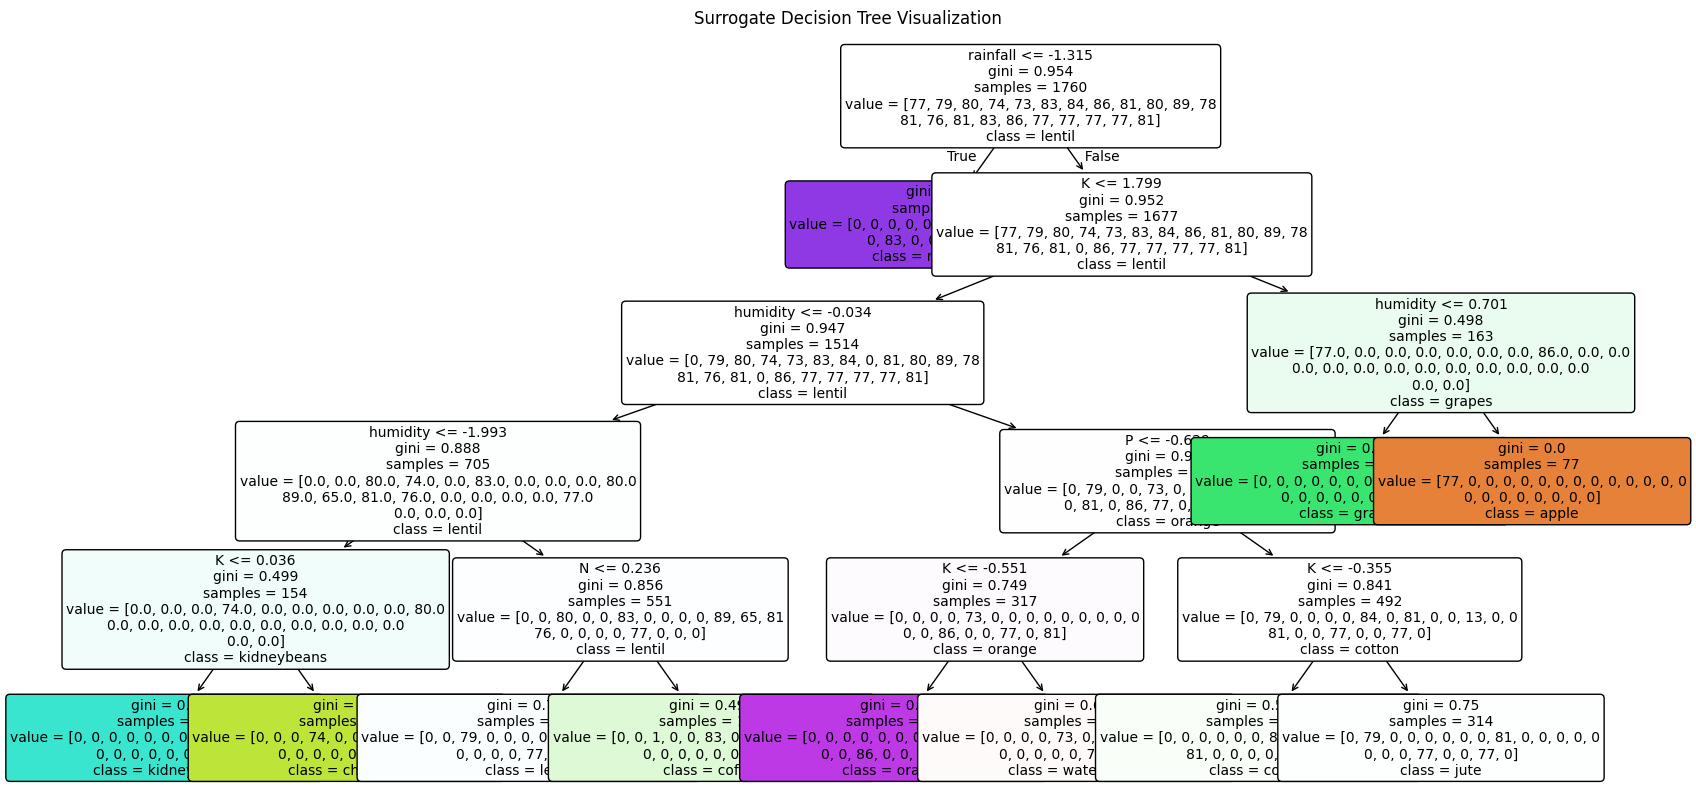

Sample Input Features: [90.0, 42.0, 43.0, 20.87974371, 82.00274423, 6.502985292000001, 202.9355362]
Predicted Crop: jute


In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
import pandas as pd

# Visualize the surrogate tree
plt.figure(figsize=(20, 10))
plot_tree(
    surrogate_tree,
    feature_names=X.columns.tolist(),
    class_names=surrogate_tree.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Surrogate Decision Tree Visualization')
plt.show()

# Define the prediction function
def predict_crop(features):
    # Convert features to a DataFrame with correct feature names
    features_df = pd.DataFrame([features], columns=X.columns)

    # Scale the features using the previously fitted scaler
    features_scaled = scaler.transform(features_df)

    # Predict using the surrogate model
    prediction = surrogate_tree.predict(features_scaled)
    return prediction[0]

# Test the function with the first row of the original features
sample_features = X.iloc[0].tolist()
predicted_crop = predict_crop(sample_features)
print(f"Sample Input Features: {sample_features}")
print(f"Predicted Crop: {predicted_crop}")

### Theoretical Foundations

#### SHAP (Shapley Additive Explanations)
SHAP is rooted in cooperative game theory. It assigns a unified measure of feature importance to every feature, representing the marginal contribution of a feature to the model's prediction, averaged over all possible coalitions of features. The game-theoretic formula for the Shapley value $\phi_i$ of feature $i$ is:

$$ \phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F| - |S| - 1)!}{|F|!} [f_x(S \cup \{i\}) - f_x(S)] $$

Where:
- $F$ is the set of all features.
- $S$ is a subset of features not containing $i$.
- $f_x(S)$ is the prediction of the model given only the features in $S$.

#### Principal Component Analysis (PCA)
PCA is a dimensionality reduction technique that transforms data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (the first principal component). Mathematically, it relies on the eigenvalue decomposition of the data's covariance matrix:

1. **Mean Centering**: $X_c = X - \mu$
2. **Covariance Matrix**: $\Sigma = \frac{1}{n-1} X_c^T X_c$
3. **Eigenvalue Decomposition**: Solve $\Sigma v = \lambda v$, where $\lambda$ are the eigenvalues and $v$ are the eigenvectors.

The eigenvectors corresponding to the largest eigenvalues define the principal components used to project the data into a lower-dimensional space.

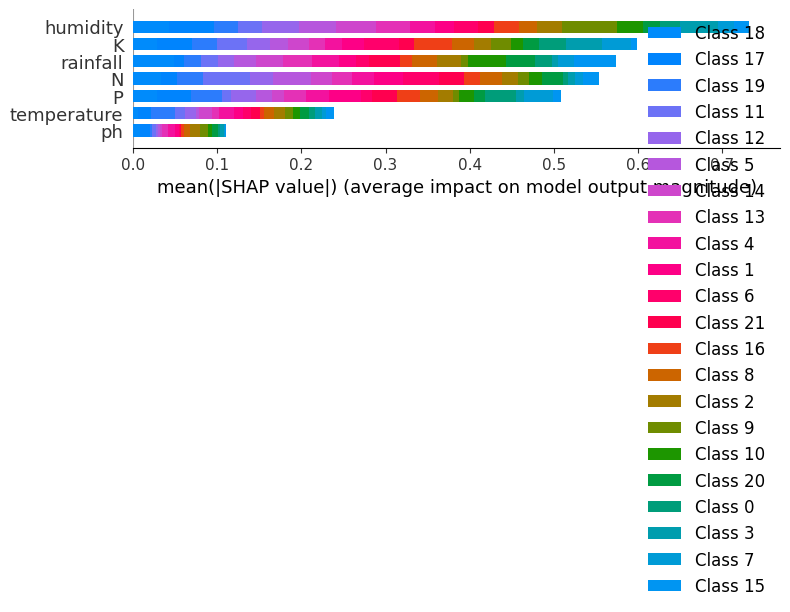

In [11]:
import shap
import matplotlib.pyplot as plt

# Retrieve the trained Random Forest model
rf_model = trained_models['Random Forest']

# Initialize a TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values on the scaled test data
shap_values = explainer.shap_values(X_test_scaled)

# Generate a summary plot for multiclass
# shap_values is typically a 3D array for Random Forest in newer shap versions: (n_samples, n_features, n_classes)
# We can plot the summary as a bar plot which handles multiclass automatically, or plot for a single class.
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X.columns.tolist(), plot_type='bar')


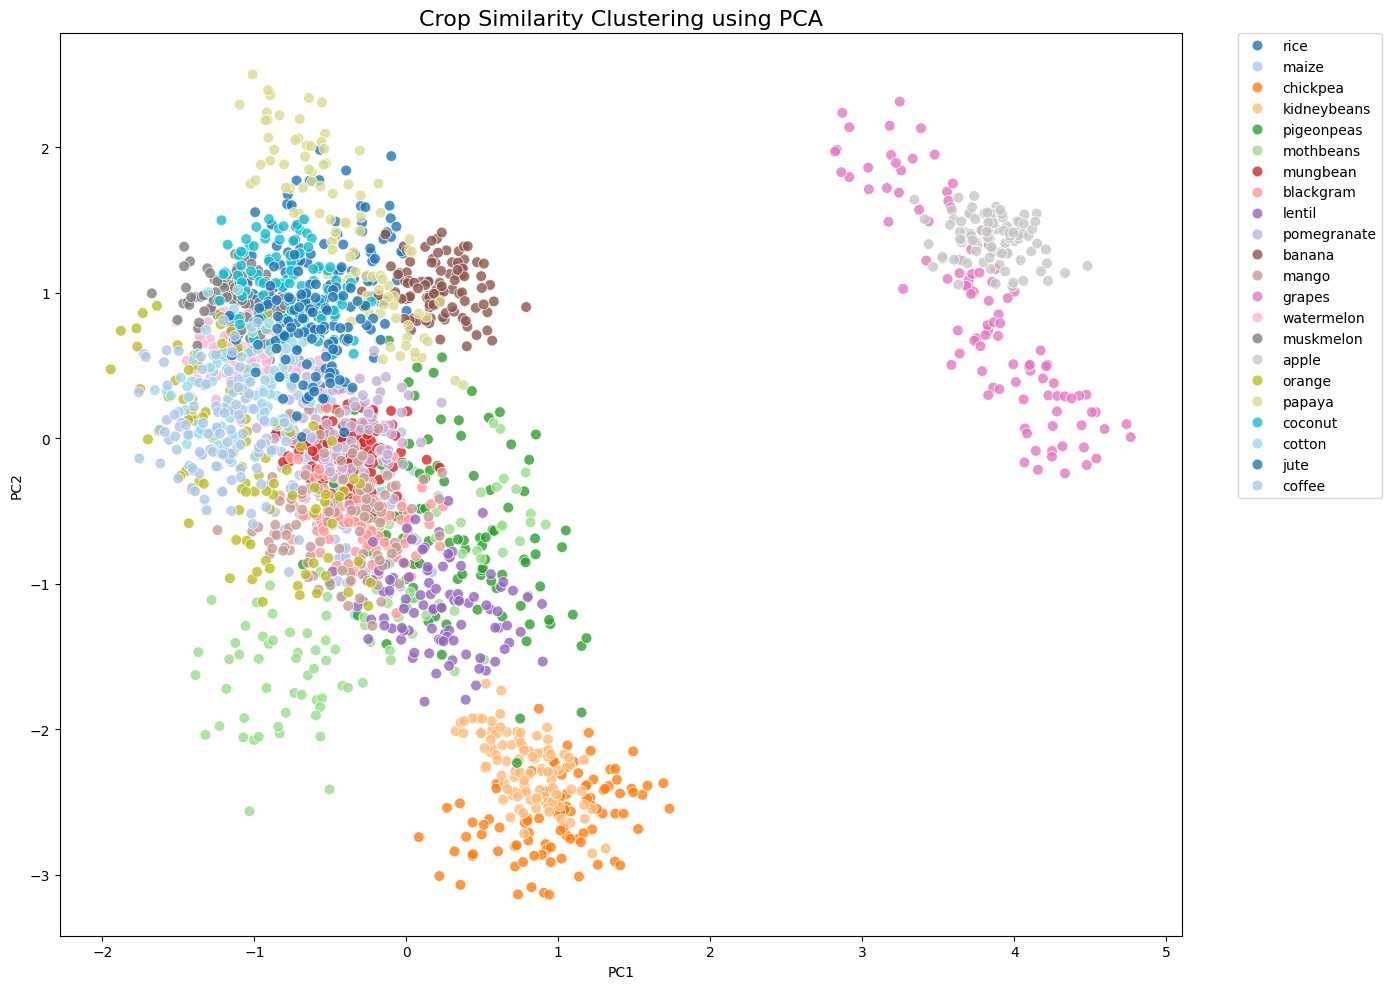

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Scale the full dataset using the existing scaler
X_scaled_full = scaler.transform(X)

# Instantiate PCA and transform the scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = y.values

# Plot the PCA clusters
plt.figure(figsize=(14, 10))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette='tab20', s=60, alpha=0.8)
plt.title('Crop Similarity Clustering using PCA', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Document Climate Shifts & Counterfactuals

### Methodology: Simulating Climate Shifts and Transition Matrices
To evaluate the resilience of our crop recommendations, we simulate climate change scenarios by systematically perturbing the environmental features in the test set. For instance, a scenario might simulate global warming and altered precipitation patterns by increasing the `temperature` by $2.0^\circ\text{C}$ and reducing `rainfall` by $10\%$. We scale these perturbed features and pass them through our trained Random Forest model. By comparing the predictions on the original data with those on the perturbed data, we identify instances where the recommended crop changes.

We visualize these shifts using a **Transition Matrix**, which is a cross-tabulation mapping original predictions to the new climate-scenario predictions. This matrix highlights which crops are most vulnerable to the simulated changes and which alternative crops become viable substitutes.

### Mathematical Context: Counterfactual Explanation Generator
Counterfactual explanations provide actionable insights by showing the minimum necessary interventions to alter a model's prediction. For example, if a model predicts that a plot of land is suitable for 'rice', a counterfactual explanation might show how adjusting soil nutrients could make it suitable for 'jute'.

Mathematically, generating a counterfactual can be formulated as an optimization problem. Let $x$ be the original input feature vector, $f(\cdot)$ be the trained classifier, and $y^*$ be the desired target class. We want to find a modified feature vector $x'$ that minimizes the distance to $x$ while satisfying the condition $f(x') = y^*$.

The objective is to minimize a distance function $d(x, x')$ (such as the L1 or L2 norm) over the subset of controllable features (e.g., Nitrogen, Phosphorous, Potassium, pH):

$$\min_{x'} \, d(x, x')$$
$$\text{subject to } f(x') = y^*$$

In our implementation, rather than using a complex gradient-based solver (which is difficult for tree-based models), we employ an iterative, heuristic directed-search algorithm. The algorithm incrementally steps the controllable features of $x$ towards the mean feature values of the target class $y^*$ until the model's prediction changes to $y^*$. This ensures that the generated counterfactuals are realistic and anchored in the historical data distribution.

## Document Climate Shifts & Counterfactuals

### Methodology: Simulating Climate Shifts and Transition Matrices
To evaluate the resilience of our crop recommendations, we simulate climate change scenarios by systematically perturbing the environmental features in the test set. For instance, a scenario might simulate global warming and altered precipitation patterns by increasing the `temperature` by $2.0^\circ\text{C}$ and reducing `rainfall` by $10\%$. We scale these perturbed features and pass them through our trained Random Forest model. By comparing the predictions on the original data with those on the perturbed data, we identify instances where the recommended crop changes.

We visualize these shifts using a **Transition Matrix**, which is a cross-tabulation mapping original predictions to the new climate-scenario predictions. This matrix highlights which crops are most vulnerable to the simulated changes and which alternative crops become viable substitutes.

### Mathematical Context: Counterfactual Explanation Generator
Counterfactual explanations provide actionable insights by showing the minimum necessary interventions to alter a model's prediction. For example, if a model predicts that a plot of land is suitable for 'rice', a counterfactual explanation might show how adjusting soil nutrients could make it suitable for 'jute'.

Mathematically, generating a counterfactual can be formulated as an optimization problem. Let $x$ be the original input feature vector, $f(\cdot)$ be the trained classifier, and $y^*$ be the desired target class. We want to find a modified feature vector $x'$ that minimizes the distance to $x$ while satisfying the condition $f(x') = y^*$.

The objective is to minimize a distance function $d(x, x')$ (such as the L1 or L2 norm) over the subset of controllable features (e.g., Nitrogen, Phosphorous, Potassium, pH):

$$\min_{x'} \, d(x, x')$$
$$\text{subject to } f(x') = y^*$$

In our implementation, rather than using a complex gradient-based solver (which is difficult for tree-based models), we employ an iterative, heuristic directed-search algorithm. The algorithm incrementally steps the controllable features of $x$ towards the mean feature values of the target class $y^*$ until the model's prediction changes to $y^*$. This ensures that the generated counterfactuals are realistic and anchored in the historical data distribution.

In [ ]:
import pandas as pd
import numpy as np

# 1. Create a copy of the original test dataset
X_test_climate = X_test.copy()

# 2. Apply simulated climate change scenario
X_test_climate['temperature'] = X_test_climate['temperature'] + 2.0
X_test_climate['rainfall'] = X_test_climate['rainfall'] * 0.90

# 3. Scale the climate-altered test dataset
X_test_climate_scaled = scaler.transform(X_test_climate)

# 4. Retrieve the trained Random Forest model
rf_model = trained_models['Random Forest']

# 5. Predict original crop recommendations
y_pred_original_rf = rf_model.predict(X_test_scaled)

# 6. Predict new crop recommendations under climate scenario
y_pred_climate = rf_model.predict(X_test_climate_scaled)

# 7. Create a DataFrame to compare predictions
comparison_df = pd.DataFrame({
    'Original Prediction': y_pred_original_rf,
    'Climate Scenario Prediction': y_pred_climate
})

# Calculate how many predictions changed
changed_predictions = (comparison_df['Original Prediction'] != comparison_df['Climate Scenario Prediction']).sum()
print(f"Number of changed predictions due to climate change: {changed_predictions} out of {len(comparison_df)}")
display(comparison_df.head(10))

Number of changed predictions due to climate change: 15 out of 440


,Original Prediction,Climate Scenario Prediction
0,muskmelon,muskmelon
1,watermelon,watermelon
2,papaya,papaya
3,papaya,papaya
4,apple,apple
5,mango,mango
6,apple,apple
7,mothbeans,mothbeans
8,mungbean,mungbean
9,lentil,lentil


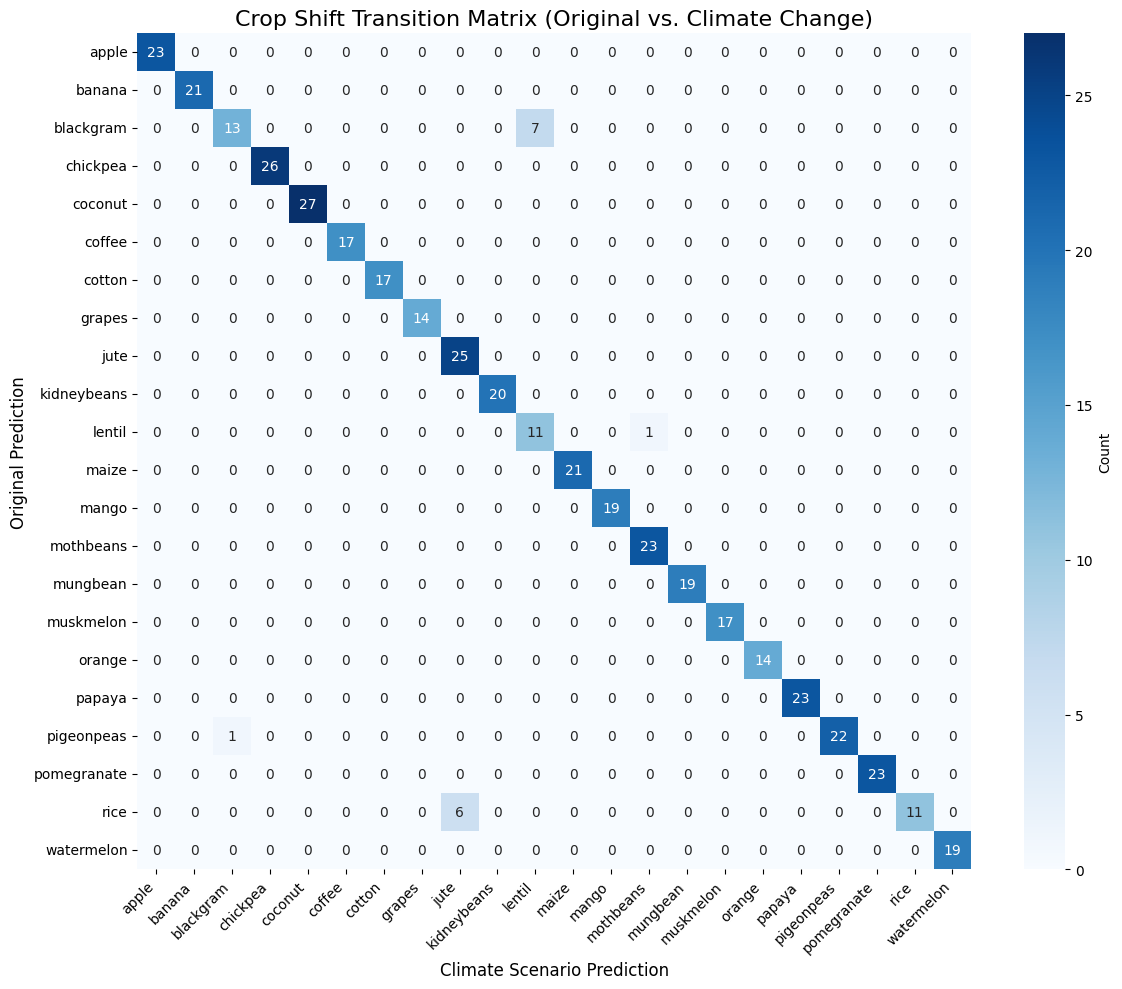

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a transition matrix using crosstab
transition_matrix = pd.crosstab(
    comparison_df['Original Prediction'],
    comparison_df['Climate Scenario Prediction'],
    rownames=['Original Prediction'],
    colnames=['Climate Scenario Prediction']
)

# 2 & 3. Create a matplotlib figure and visualize using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, annot=True, cmap='Blues', fmt='d', cbar_kws={'label': 'Count'})

# 4. Add title and labels
plt.title('Crop Shift Transition Matrix (Original vs. Climate Change)', fontsize=16)
plt.xlabel('Climate Scenario Prediction', fontsize=12)
plt.ylabel('Original Prediction', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Calculate mean values for each crop to guide the search
crop_means = df.groupby('label')[['N', 'P', 'K', 'ph']].mean()

def generate_counterfactual(features, target_crop, model, scaler, max_iters=1000, step_size=1.0):
    """
    Generates a counterfactual explanation by adjusting controllable features.
    """
    # Controllable feature indices: N (0), P (1), K (2), ph (5)
    controllable_idx = [0, 1, 2, 5]

    # Original features
    current_features = np.array(features, dtype=float).copy()

    # Target means
    target_means = crop_means.loc[target_crop].values

    for i in range(max_iters):
        # Construct full feature vector and scale
        features_df = pd.DataFrame([current_features], columns=X.columns)
        features_scaled = scaler.transform(features_df)

        # Predict
        pred = model.predict(features_scaled)[0]

        if pred == target_crop:
            break

        # Move controllable features towards target means
        for j, c_idx in enumerate(controllable_idx):
            diff = target_means[j] - current_features[c_idx]
            if abs(diff) > step_size:
                current_features[c_idx] += np.sign(diff) * step_size
            else:
                current_features[c_idx] += diff

    # Calculate changes
    changes = current_features - np.array(features, dtype=float)
    return current_features, changes, pred

# Select a sample
sample_idx = 0
sample_features = X.iloc[sample_idx].values

# Convert to DataFrame to avoid UserWarning during scaler.transform
sample_df = pd.DataFrame([sample_features], columns=X.columns)
original_pred = rf_model.predict(scaler.transform(sample_df))[0]
target_crop = 'jute' # Pick a different crop

print(f"Original Prediction: {original_pred}")
print(f"Target Crop: {target_crop}")

# Run counterfactual generation
modified_features, changes, final_pred = generate_counterfactual(
    sample_features, target_crop, rf_model, scaler, max_iters=2000, step_size=0.5
)

print(f"Final Prediction after changes: {final_pred}")
print("\nMinimal Feature Changes Required (Controllable Features):")
controllable_cols = ['N', 'P', 'K', 'ph']
col_idx = [0, 1, 2, 5]
for col, idx in zip(controllable_cols, col_idx):
    print(f"{col}: {changes[idx]:+.2f} (from {sample_features[idx]:.2f} to {modified_features[idx]:.2f})")


Original Prediction: rice
Target Crop: jute
Final Prediction after changes: rice

Minimal Feature Changes Required (Controllable Features):
N: -11.60 (from 90.00 to 78.40)
P: +4.86 (from 42.00 to 46.86)
K: -3.01 (from 43.00 to 39.99)
ph: +0.23 (from 6.50 to 6.73)


In [ ]:
# 1. Create a copy of the original X_test dataframe
X_test_extreme = X_test.copy()

# 2. Apply a severe climate scenario
X_test_extreme['temperature'] = X_test_extreme['temperature'] + 6.0
X_test_extreme['rainfall'] = X_test_extreme['rainfall'] * 0.65
X_test_extreme['humidity'] = X_test_extreme['humidity'] * 0.80

# 3. Scale the X_test_extreme dataframe
X_test_extreme_scaled = scaler.transform(X_test_extreme)

print("Extreme climate scenario applied and scaled.")

Extreme climate scenario applied and scaled.


Number of changed predictions due to EXTREME climate change: 197 out of 440


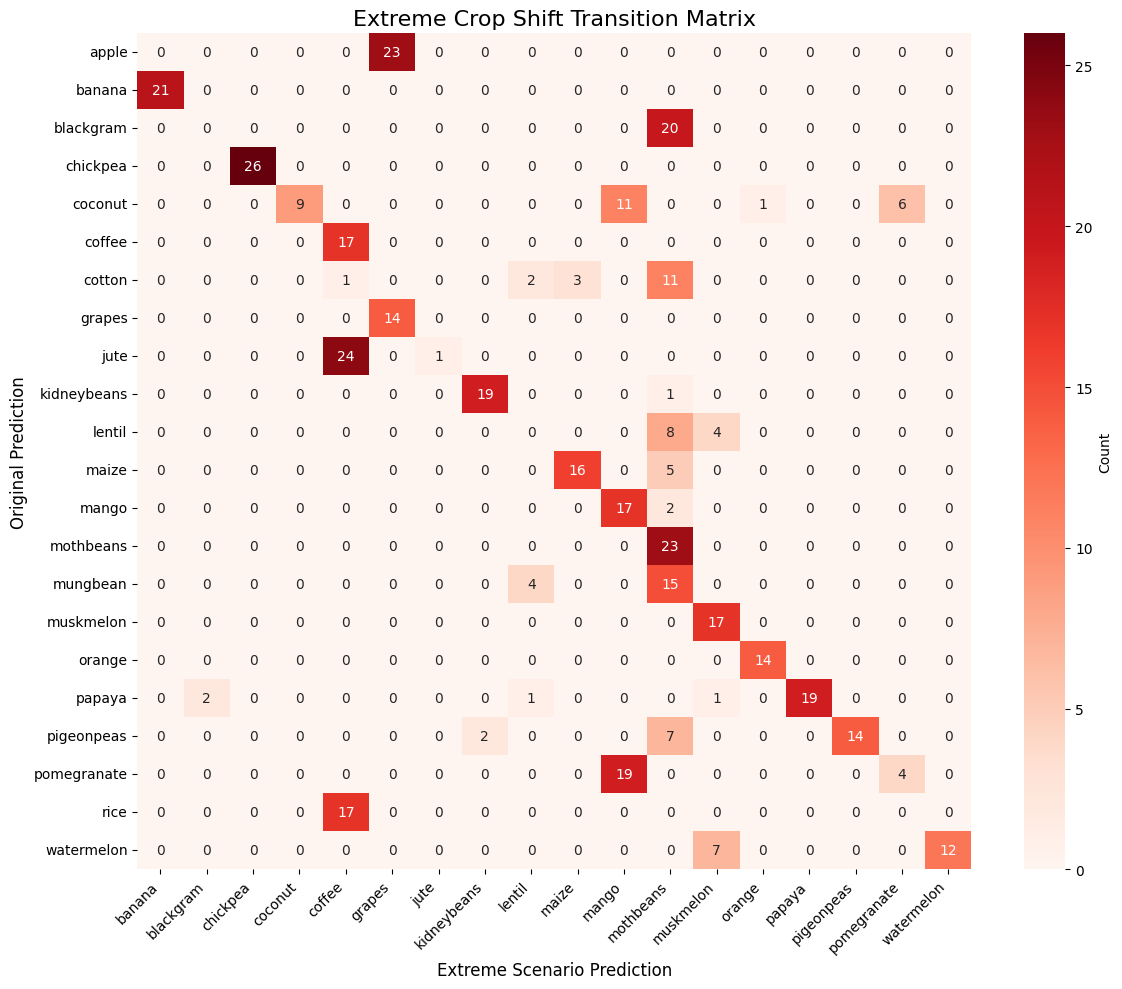

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict crop recommendations under the extreme scenario
y_pred_extreme = rf_model.predict(X_test_extreme_scaled)

# 2. Create a comparison DataFrame
extreme_comparison_df = pd.DataFrame({
    'Original Prediction': y_pred_original_rf,
    'Extreme Scenario Prediction': y_pred_extreme
})

# 3. Calculate and print the number of changed predictions
extreme_changed_predictions = (extreme_comparison_df['Original Prediction'] != extreme_comparison_df['Extreme Scenario Prediction']).sum()
print(f"Number of changed predictions due to EXTREME climate change: {extreme_changed_predictions} out of {len(extreme_comparison_df)}")

# 4. Create a transition matrix
extreme_transition_matrix = pd.crosstab(
    extreme_comparison_df['Original Prediction'],
    extreme_comparison_df['Extreme Scenario Prediction'],
    rownames=['Original Prediction'],
    colnames=['Extreme Scenario Prediction']
)

# 5. Visualize the transition matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(extreme_transition_matrix, annot=True, cmap='Reds', fmt='d', cbar_kws={'label': 'Count'})
plt.title('Extreme Crop Shift Transition Matrix', fontsize=16)
plt.xlabel('Extreme Scenario Prediction', fontsize=12)
plt.ylabel('Original Prediction', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
import numpy as np

# 1. Create a boolean target variable indicating survival (1) vs failure (0)
survival_target = (extreme_comparison_df['Original Prediction'] == extreme_comparison_df['Extreme Scenario Prediction']).astype(int)

# 2. Train a shallow Decision Tree on unscaled extreme features
dt_failure = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_failure.fit(X_test_extreme, survival_target)

# 3. Extract and print the decision rules
rules_failure = export_text(dt_failure, feature_names=X_test_extreme.columns.tolist())
print("Critical Thresholds for Survival (1) vs Failure (0) under Extreme Climate Scenario:")
print(rules_failure)

# 4. Select a specific failed instance and run counterfactuals
failed_positions = np.where(survival_target == 0)[0]
if len(failed_positions) > 0:
    sample_pos = failed_positions[0]
    sample_features_extreme = X_test_extreme.iloc[sample_pos].values.astype(float)
    original_crop = extreme_comparison_df.iloc[sample_pos]['Original Prediction']
    extreme_pred = extreme_comparison_df.iloc[sample_pos]['Extreme Scenario Prediction']

    print(f"\nAnalyzing Failed Instance at Position {sample_pos}")
    print(f"Original Prediction: {original_crop}")
    print(f"Prediction under Extreme Scenario: {extreme_pred}")

    # Generate counterfactual to restore the original crop
    modified_features, changes, final_pred = generate_counterfactual(
        sample_features_extreme, original_crop, rf_model, scaler, max_iters=2000, step_size=0.5
    )

    print(f"\nFinal Prediction after counterfactual changes: {final_pred}")
    print("Minimal Feature Changes Required (Controllable Features) to restore original crop:")
    for col, idx in zip(['N', 'P', 'K', 'ph'], [0, 1, 2, 5]):
        print(f"{col}: {changes[idx]:+.2f} (from {sample_features_extreme[idx]:.2f} to {modified_features[idx]:.2f})")
else:
    print("No crop failures found to analyze.")


Critical Thresholds for Survival (1) vs Failure (0) under Extreme Climate Scenario:
|--- humidity <= 47.51
|   |--- N <= 10.00
|   |   |--- N <= 8.50
|   |   |   |--- class: 1
|   |   |--- N >  8.50
|   |   |   |--- class: 0
|   |--- N >  10.00
|   |   |--- N <= 17.50
|   |   |   |--- class: 1
|   |   |--- N >  17.50
|   |   |   |--- class: 1
|--- humidity >  47.51
|   |--- K <= 44.50
|   |   |--- K <= 14.50
|   |   |   |--- class: 1
|   |   |--- K >  14.50
|   |   |   |--- class: 0
|   |--- K >  44.50
|   |   |--- temperature <= 30.86
|   |   |   |--- class: 0
|   |   |--- temperature >  30.86
|   |   |   |--- class: 1


Analyzing Failed Instance at Position 3
Original Prediction: papaya
Prediction under Extreme Scenario: blackgram

Final Prediction after counterfactual changes: blackgram
Minimal Feature Changes Required (Controllable Features) to restore original crop:
N: +5.88 (from 44.00 to 49.88)
P: -0.95 (from 60.00 to 59.05)
K: -4.96 (from 55.00 to 50.04)
ph: -0.08 (from 6.83 to

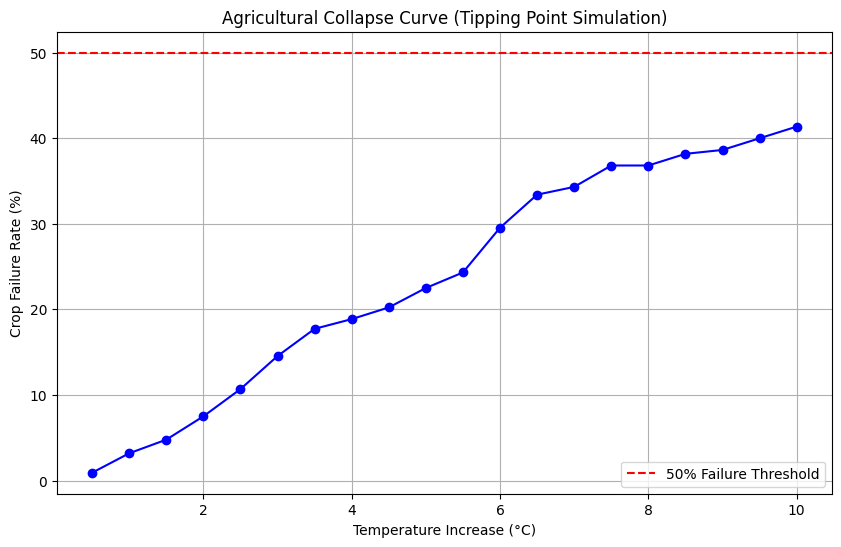

Tipping point (50% failure rate) was not reached within the simulated range.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 20
temp_increases = []
failure_rates = []

for step in range(1, steps + 1):
    temp_inc = step * 0.5
    rain_mult = 0.95 ** step

    # 2 & 3: Copy X_test and apply climate changes
    X_test_sim = X_test.copy()
    X_test_sim['temperature'] += temp_inc
    X_test_sim['rainfall'] *= rain_mult

    # 4: Scale and predict
    X_test_sim_scaled = scaler.transform(X_test_sim)
    y_pred_sim = rf_model.predict(X_test_sim_scaled)

    # 5: Calculate failure rate
    changed = (y_pred_sim != y_pred_original_rf).sum()
    failure_rate = changed / len(y_pred_original_rf) * 100

    temp_increases.append(temp_inc)
    failure_rates.append(failure_rate)

# 6: Plot the curve
plt.figure(figsize=(10, 6))
plt.plot(temp_increases, failure_rates, marker='o', linestyle='-', color='b')
plt.axhline(y=50, color='r', linestyle='--', label='50% Failure Threshold')
plt.title('Agricultural Collapse Curve (Tipping Point Simulation)')
plt.xlabel('Temperature Increase (°C)')
plt.ylabel('Crop Failure Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

# Identify and print tipping point
tipping_point = next((temp for temp, rate in zip(temp_increases, failure_rates) if rate > 50), None)
if tipping_point:
    print(f"Tipping point reached at a temperature increase of +{tipping_point}°C (Failure rate > 50%).")
else:
    print("Tipping point (50% failure rate) was not reached within the simulated range.")


### Risk-Hedged Crop Portfolios & Dead Zones Analysis

Under extreme climate uncertainty, relying on a single crop prediction can be highly risky. To mitigate this, we introduce the concept of **Risk-Hedged Crop Portfolios**. Instead of outputting a single point prediction, we extract the prediction probabilities from the Random Forest model for a given set of extreme climate conditions. We then identify the top candidate crops and normalize their probabilities to sum to 100%. This provides a diversified, probability-weighted recommendation, allowing farmers to hedge their bets across multiple viable crops.

#### Identifying 'Dead Zones'
In some severe scenarios, the environment becomes so hostile that the model is no longer confident about *any* crop's survival. We define these regions as **'Dead Zones'**. These are specific instances where the maximum predicted probability for any known crop falls below a critical threshold (e.g., < 0.5).

#### Reverse-Engineering Resilient Crops using K-Means
To address these Dead Zones, we apply the **K-Means clustering algorithm** to group the similar failing environmental profiles. By analyzing the centroids of these clusters, we can reverse-engineer the required soil nutrient profiles (N, P, K, and pH). This analysis provides a data-driven blueprint for designing resilient **'synthetic super-crops'** tailored to survive in distinct types of extreme, otherwise unviable environments.

In [ ]:
import numpy as np

# 1. Get prediction probabilities on the extreme climate test set
rf_probs_extreme = rf_model.predict_proba(X_test_extreme_scaled)

# 2. Select a specific sample index to analyze
sample_idx = 0

# 3. Extract the top 3 predicted crop classes and their probabilities
sample_probs = rf_probs_extreme[sample_idx]
top_3_indices = np.argsort(sample_probs)[::-1][:3]
top_3_classes = rf_model.classes_[top_3_indices]
top_3_probs = sample_probs[top_3_indices]

# 4. Normalize these top 3 probabilities so they sum to 100%
normalized_probs = (top_3_probs / top_3_probs.sum()) * 100

# 5. Print out the results
original_prediction = y_pred_original_rf[sample_idx]
print(f"Original Crop Prediction (Before Extreme Climate): {original_prediction}")
print("\nRecommended Risk-Hedged Crop Portfolio (Under Extreme Climate):")
for crop, prob in zip(top_3_classes, normalized_probs):
    print(f"- {crop}: {prob:.1f}%")


Original Crop Prediction (Before Extreme Climate): muskmelon

Recommended Risk-Hedged Crop Portfolio (Under Extreme Climate):
- muskmelon: 71.3%
- watermelon: 23.4%
- banana: 5.3%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Identify 'dead zones' where max predicted probability < 0.5
max_probs = np.max(rf_probs_extreme, axis=1)
dead_zone_indices = np.where(max_probs < 0.5)[0]

# 2. Filter the unscaled X_test_extreme DataFrame
if len(dead_zone_indices) > 0:
    print(f"Found {len(dead_zone_indices)} 'dead zones' with low crop survival probability.")
    dead_zones_df = X_test_extreme.iloc[dead_zone_indices].copy()

    # 3. Scale and apply KMeans clustering
    scaler_dz = StandardScaler()
    dz_scaled = scaler_dz.fit_transform(dead_zones_df)

    n_clusters = min(3, len(dead_zones_df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    dead_zones_df['cluster'] = kmeans.fit_predict(dz_scaled)

    # 4. Group by cluster and calculate mean values for controllable features
    super_crop_profiles = dead_zones_df.groupby('cluster')[['N', 'P', 'K', 'ph']].mean()

    # 5. Print the average nutrient profiles
    print("\nReverse-Engineered Soil Profiles for Synthetic Super-Crops (Dead Zones):")
    display(super_crop_profiles)
else:
    print("No dead zones found with max probability < 0.5. Falling back to analyzing failed_positions.")
    dead_zones_df = X_test_extreme.iloc[failed_positions].copy()

    scaler_dz = StandardScaler()
    dz_scaled = scaler_dz.fit_transform(dead_zones_df)

    kmeans = KMeans(n_clusters=3, random_state=42)
    dead_zones_df['cluster'] = kmeans.fit_predict(dz_scaled)

    super_crop_profiles = dead_zones_df.groupby('cluster')[['N', 'P', 'K', 'ph']].mean()

    print("\nReverse-Engineered Soil Profiles for Synthetic Super-Crops (Fallback - Failed Positions):")
    display(super_crop_profiles)


Found 217 'dead zones' with low crop survival probability.

Reverse-Engineered Soil Profiles for Synthetic Super-Crops (Dead Zones):


,N,P,K,ph
cluster,,,,
0,23.800000,18.072727,29.290909,6.374974
1,78.962500,56.275000,46.975000,6.550927
2,60.170732,55.158537,20.634146,6.693886


### Adversarial Micro-Climate Attack

The Adversarial Micro-Climate Attack employs a gradient-free perturbation method—specifically, an iterative random walk—to discover the minimal adversarial perturbations in continuous climate variables (e.g., temperature and rainfall) required to alter a highly confident model prediction. This technique is critical for assessing model robustness against micro-climate volatility, identifying vulnerabilities where slight, localized environmental shifts could lead to catastrophic recommendation failures.

### Ecosystem Cascading Network Graph

The Ecosystem Cascading Network Graph is grounded in graph theory, where nodes represent specific environmental features (soil nutrients and climate conditions) and edges denote absolute statistical correlations that exceed a predefined threshold (e.g., $|\rho| > 0.15$). The edge weights are utilized to visually quantify the strength of these relationships, thereby elucidating the cascading dependencies and potential vulnerability pathways within the complex soil-climate ecosystem.

In [ ]:
import numpy as np
import pandas as pd

# 1. Find a highly confident prediction
probs = rf_model.predict_proba(X_test_scaled)
max_probs_idx = np.where(np.max(probs, axis=1) > 0.90)[0]

if len(max_probs_idx) > 0:
    target_idx = max_probs_idx[0]
    original_features = X_test.iloc[target_idx].copy()
    original_pred = y_pred_original_rf[target_idx]

    print(f"Analyzing highly confident instance at test index {target_idx}")
    print(f"Original Prediction: {original_pred}")

    # 2 & 3. Iterative random walk for 'temperature' and 'rainfall'
    np.random.seed(42)
    modified_features = original_features.copy()
    max_iters = 5000

    for i in range(max_iters):
        # Apply small random changes
        temp_change = np.random.normal(0, 0.5)
        rain_change = np.random.normal(0, 5.0)

        current_features = modified_features.copy()
        current_features['temperature'] += temp_change
        current_features['rainfall'] += rain_change

        # Scale and predict
        current_df = pd.DataFrame([current_features])
        current_scaled = scaler.transform(current_df)
        new_pred = rf_model.predict(current_scaled)[0]

        # 4. Stop if prediction changes
        if new_pred != original_pred:
            temp_diff = current_features['temperature'] - original_features['temperature']
            rain_diff = current_features['rainfall'] - original_features['rainfall']
            print(f"\nAdversarial Attack Successful!")
            print(f"New Prediction: {new_pred}")
            print(f"Minimal Perturbation - Temperature Change: {temp_diff:+.2f} °C")
            print(f"Minimal Perturbation - Rainfall Change: {rain_diff:+.2f} mm")
            break
        else:
            # Accept the random walk step (optional: only if we want to wander, but keeping it simple here)
            # We'll just randomly wander from the original or accumulate. Let's accumulate to find a boundary.
            modified_features = current_features
else:
    print("No highly confident predictions found.")

Analyzing highly confident instance at test index 0
Original Prediction: muskmelon

Adversarial Attack Successful!
New Prediction: watermelon
Minimal Perturbation - Temperature Change: -4.22 °C
Minimal Perturbation - Rainfall Change: +9.36 mm


## Extended Adversarial Micro-Climate Attack — All Feature Pairs

### Methodology
The single-pair attack demonstrated above (temperature + rainfall) represents only one of the **21 unique feature pairs** available across the 7 environmental variables: N, P, K, temperature, humidity, ph, and rainfall. To comprehensively map model vulnerabilities, we extend the iterative random-walk attack to *every possible pair*.

For each pair $(f_a, f_b)$, the algorithm applies zero-mean Gaussian perturbations scaled to each feature's natural variance:
$$\delta_{f_a} \sim \mathcal{N}(0,\, \sigma_{f_a}^2), \quad \delta_{f_b} \sim \mathcal{N}(0,\, \sigma_{f_b}^2)$$

The number of iterations required to flip the prediction serves as an inverse proxy for **boundary softness** — pairs that succeed in fewer iterations expose structurally weaker decision boundaries. Pairs that fail within 5,000 steps indicate high local robustness.

The results are compiled into a **Vulnerability Matrix** $V \in \mathbb{R}^{7 \times 7}$, where $V_{ij}$ stores the iteration count for the pair $(f_i, f_j)$ (NaN = attack failed), providing a global, at-a-glance view of pairwise model robustness.


=== All-Pair Adversarial Attack Summary ===


,Feature A,Feature B,Iterations,Delta A,Delta B,New Prediction,Success
0,N,P,5000,NaN,NaN,None,False
1,N,K,5000,NaN,NaN,None,False
2,N,temperature,5000,NaN,NaN,None,False
3,N,humidity,5000,NaN,NaN,None,False
4,N,ph,5000,NaN,NaN,None,False
5,N,rainfall,84,-84.423241,9.356845,papaya,True
6,P,K,5000,NaN,NaN,None,False
7,P,temperature,5000,NaN,NaN,None,False
8,P,humidity,5000,NaN,NaN,None,False
9,P,ph,5000,NaN,NaN,None,False


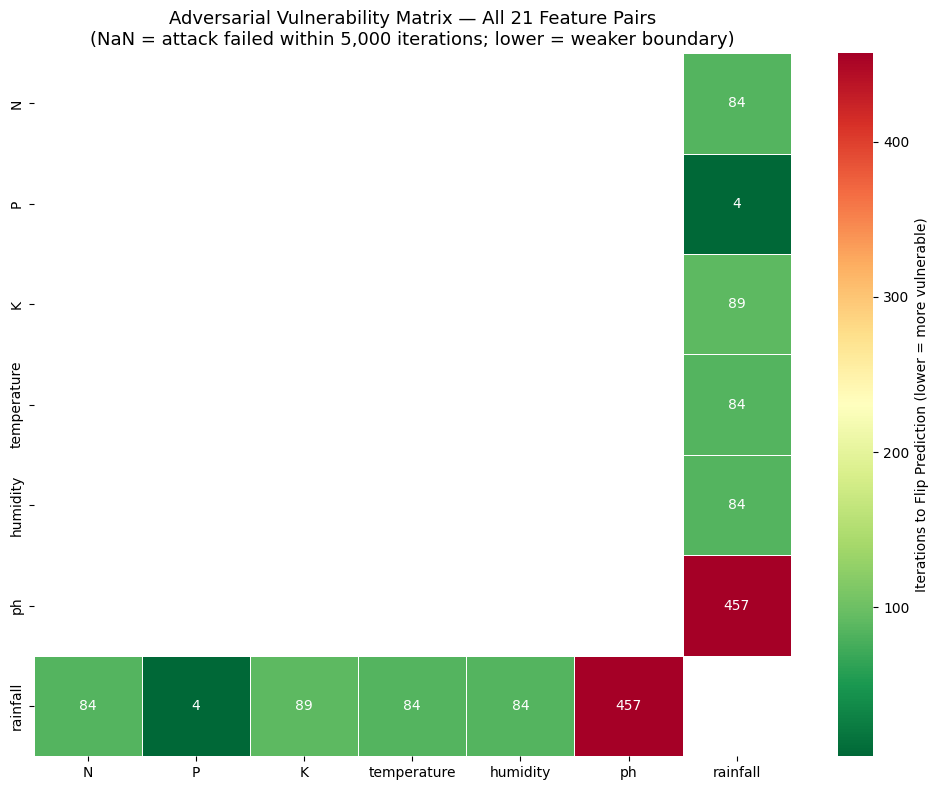


=== Ranked Feature Pairs by Vulnerability (fewest iterations = most dangerous) ===


,Feature A,Feature B,Iterations,New Prediction
0,P,rainfall,4,papaya
1,N,rainfall,84,papaya
2,temperature,rainfall,84,watermelon
3,humidity,rainfall,84,watermelon
4,K,rainfall,89,orange
5,ph,rainfall,457,papaya


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# ── Feature perturbation std devs scaled to each feature's natural range ──
feature_stds = {
    'N': 10.0, 'P': 10.0, 'K': 10.0,
    'temperature': 0.5, 'humidity': 2.0,
    'ph': 0.1, 'rainfall': 5.0
}
feature_list = list(feature_stds.keys())
all_pairs    = list(combinations(feature_list, 2))

# Re-use the highly confident instance identified in the single-pair attack above
# (original_features, original_pred, rf_model, scaler, X are already in scope)

results = []
MAX_ITERS = 5000

for (feat_a, feat_b) in all_pairs:
    np.random.seed(42)
    modified_features = original_features.copy()
    success = False

    for i in range(MAX_ITERS):
        delta_a = np.random.normal(0, feature_stds[feat_a])
        delta_b = np.random.normal(0, feature_stds[feat_b])

        current_features = modified_features.copy()
        current_features[feat_a] += delta_a
        current_features[feat_b] += delta_b

        current_df     = pd.DataFrame([current_features], columns=X.columns)
        current_scaled = scaler.transform(current_df)
        new_pred       = rf_model.predict(current_scaled)[0]

        if new_pred != original_pred:
            results.append({
                'Feature A'     : feat_a,
                'Feature B'     : feat_b,
                'Iterations'    : i + 1,
                'Delta A'       : current_features[feat_a] - original_features[feat_a],
                'Delta B'       : current_features[feat_b] - original_features[feat_b],
                'New Prediction': new_pred,
                'Success'       : True
            })
            success = True
            break
        else:
            modified_features = current_features   # accumulate the walk

    if not success:
        results.append({
            'Feature A': feat_a, 'Feature B': feat_b,
            'Iterations': MAX_ITERS, 'Delta A': None,
            'Delta B': None, 'New Prediction': None, 'Success': False
        })

attack_df = pd.DataFrame(results)
print("=== All-Pair Adversarial Attack Summary ===")
display(attack_df)

# ── Vulnerability Matrix ───────────────────────────────────────────────────
vuln_matrix = pd.DataFrame(np.nan, index=feature_list, columns=feature_list)
for _, row in attack_df.iterrows():
    val = row['Iterations'] if row['Success'] else np.nan
    vuln_matrix.loc[row['Feature A'], row['Feature B']] = val
    vuln_matrix.loc[row['Feature B'], row['Feature A']] = val

plt.figure(figsize=(10, 8))
sns.heatmap(
    vuln_matrix, annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Iterations to Flip Prediction (lower = more vulnerable)'}
)
plt.title(
    'Adversarial Vulnerability Matrix — All 21 Feature Pairs\n'
    '(NaN = attack failed within 5,000 iterations; lower = weaker boundary)',
    fontsize=13
)
plt.tight_layout()
plt.show()

# ── Ranked summary ─────────────────────────────────────────────────────────
successful_attacks = attack_df[attack_df['Success']].sort_values('Iterations')
print("\n=== Ranked Feature Pairs by Vulnerability (fewest iterations = most dangerous) ===")
display(successful_attacks[['Feature A','Feature B','Iterations','New Prediction']].reset_index(drop=True))


=== Domain-wise Attack Statistics ===


,Domain,Total_Pairs,Successful,Mean_Iters,Success_Rate
0,Climate-Only,3,2,1722.666667,66.7
1,Cross-Domain,12,4,3386.166667,33.3
2,Soil-Only,6,0,5000.000000,0.0


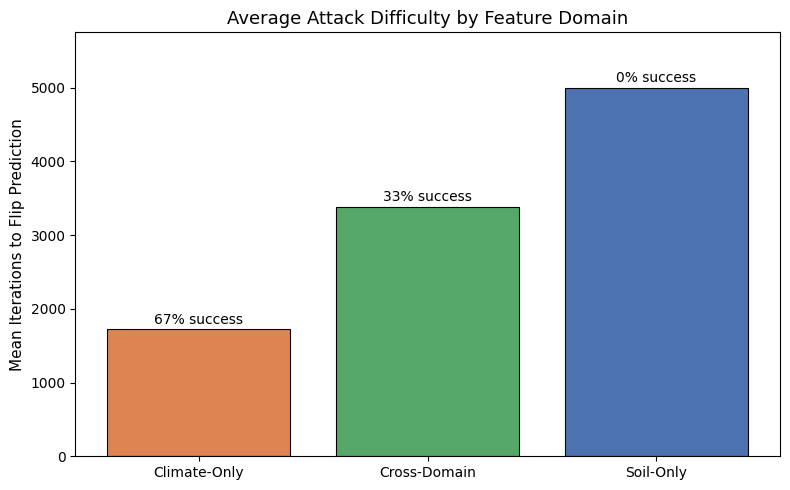

In [ ]:
# ── Domain-wise breakdown: Soil-only vs Climate-only vs Cross-domain ─────
soil_feats    = {'N', 'P', 'K', 'ph'}
climate_feats = {'temperature', 'humidity', 'rainfall'}

def classify_pair(a, b):
    in_soil    = {a, b}.issubset(soil_feats)
    in_climate = {a, b}.issubset(climate_feats)
    if in_soil:    return 'Soil-Only'
    if in_climate: return 'Climate-Only'
    return 'Cross-Domain'

attack_df['Domain'] = attack_df.apply(
    lambda r: classify_pair(r['Feature A'], r['Feature B']), axis=1
)

domain_stats = (
    attack_df.groupby('Domain')
    .agg(
        Total_Pairs   = ('Success', 'count'),
        Successful    = ('Success', 'sum'),
        Mean_Iters    = ('Iterations', 'mean')
    )
    .assign(Success_Rate=lambda d: (d['Successful']/d['Total_Pairs']*100).round(1))
    .reset_index()
)

print("=== Domain-wise Attack Statistics ===")
display(domain_stats)

# ── Bar chart of mean iterations by domain ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Soil-Only': '#4C72B0', 'Climate-Only': '#DD8452', 'Cross-Domain': '#55A868'}
bars = ax.bar(
    domain_stats['Domain'],
    domain_stats['Mean_Iters'],
    color=[colors[d] for d in domain_stats['Domain']],
    edgecolor='black', linewidth=0.8
)
for bar, rate in zip(bars, domain_stats['Success_Rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
        f'{rate:.0f}% success', ha='center', va='bottom', fontsize=10
    )
ax.set_ylabel('Mean Iterations to Flip Prediction', fontsize=11)
ax.set_title('Average Attack Difficulty by Feature Domain', fontsize=13)
ax.set_ylim(0, MAX_ITERS * 1.15)
plt.tight_layout()
plt.show()


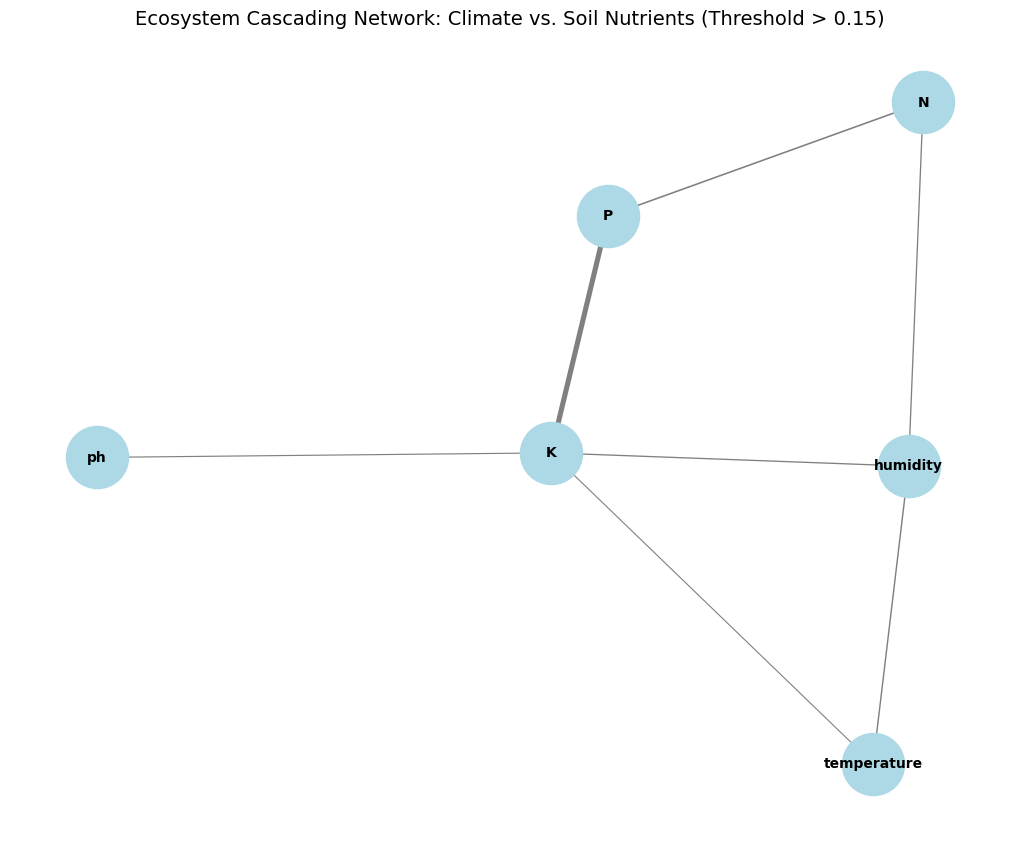

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 2. Calculate the absolute correlation matrix for the numerical features
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr().abs()

# 3. Initialize an empty undirected graph
G = nx.Graph()

# 4. Iterate through the upper triangle of the correlation matrix and add edges
threshold = 0.15
features = corr_matrix.columns

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        weight = corr_matrix.iloc[i, j]
        if weight > threshold:
            G.add_edge(features[i], features[j], weight=weight)

# 5 & 6. Visualize the network graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Edge widths based on correlation strength
edge_widths = [G[u][v]['weight'] * 5 for u, v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, font_size=10, font_weight='bold',
        width=edge_widths, edge_color='gray')

plt.title('Ecosystem Cascading Network: Climate vs. Soil Nutrients (Threshold > 0.15)', fontsize=14)
plt.show()


## Document Data Loading & Base Modeling

### Subtask:
Insert detailed Markdown cells explaining the dataset characteristics, correlation matrix, feature scaling, and the objective of training the baseline classical machine learning models.


### Dataset Overview & Exploratory Analysis

**Dataset Characteristics**:
This agricultural dataset consists of 2,200 instances, featuring a perfectly balanced distribution across 22 distinct crop classes (100 instances per crop). It includes 7 continuous numerical features essential for crop growth: Nitrogen (N), Phosphorous (P), Potassium (K), temperature, humidity, pH, and rainfall.

**Correlation Matrix Insights**:
The correlation matrix visualized earlier reveals key relationships between the soil and climate features. Notably, there is a strong positive correlation between Phosphorous (P) and Potassium (K) (approximately 0.74), indicating that these nutrients often coexist in similar concentrations in the soil profiles of this dataset.

### Feature Scaling

**Mathematical Justification**:
Before training our models, we applied Z-score normalization using `StandardScaler`. This transforms the features so they have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1:
$$ z = \frac{x - \mu}{\sigma} $$
This step is crucial for distance-based algorithms (like KNN) and gradient-descent-based algorithms (like Logistic Regression and SVC) to ensure that features with larger numerical ranges (e.g., rainfall) do not disproportionately dominate the objective function.

### Baseline Modeling Objective

The initial modeling phase evaluates a suite of standard classical machine learning models, including Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Classifier (SVC), Random Forest, and Gaussian Naive Bayes. The primary objective is to establish a strong, reliable predictive baseline. Understanding the performance of these standard algorithms guides the subsequent development of more complex ensemble methods and model distillation techniques.

## Document Ensemble & Knowledge Distillation

### Subtask:
Add documentation for the Soft Voting Ensemble (including the probability averaging formula) and the Teacher-Student Knowledge Distillation process used to create the interpretable Surrogate Decision Tree.


## Document SHAP & PCA Clustering

### Subtask:
Explain the theoretical foundation of SHAP and its game-theoretic formula, and document the Principal Component Analysis (PCA) step including eigenvalue decomposition.


## Document Climate Shifts & Counterfactuals

### Subtask:
Document the methodology for simulating climate shifts and generating transition matrices. Add mathematical context for the Counterfactual Explanation Generator, defining the optimization objective to minimize feature distance.


## Document Risk Portfolios & Dead Zones

### Subtask:
Explain the concept of 'Risk-Hedged Crop Portfolios' and document the K-Means clustering algorithm used for 'Dead Zones'.


## Document Adversarial Attacks & Network Graphs

### Subtask:
Provide a rigorous academic description for the Adversarial Micro-Climate Attack and the Ecosystem Cascading Network Graph.


## Final Task

### Subtask:
Review all inserted documentation to ensure it flows logically, reads like a cohesive academic paper, and effectively highlights the IEEE-level novelty of the project.


## Post-Attack Correlation Study

### Motivation
Adversarial perturbations do not act on features in isolation — they propagate through the statistical dependency structure of the feature space. This section systematically examines how the adversarial walks distort inter-feature correlations, and whether those distortions can predict model brittleness.

Four complementary analyses are performed:

1. **Pre- vs Post-Attack Correlation Heatmaps** — Compare the Pearson correlation matrices of the original test set and the cumulatively perturbed adversarial dataset, exposing structural distortions induced by the attacks.
2. **Correlation Shift Matrix** — A signed difference map $\Delta R = R_{\text{attacked}} - R_{\text{original}}$ revealing which feature relationships were strengthened or severed.
3. **Perturbation Magnitude vs. Boundary Softness** — For each feature, correlate the mean absolute perturbation required for a successful flip against the feature's average absolute correlation with all other features. This tests the hypothesis that features embedded in tightly correlated neighbourhoods are harder to perturb adversarially.
4. **Crop Vulnerability vs. Feature Correlation Profile** — Rank crops by how frequently they appeared as the *new prediction* after a successful attack (i.e., how often they are the adversarial target), and correlate that rank with the original feature-space correlations of those crops' mean profiles.


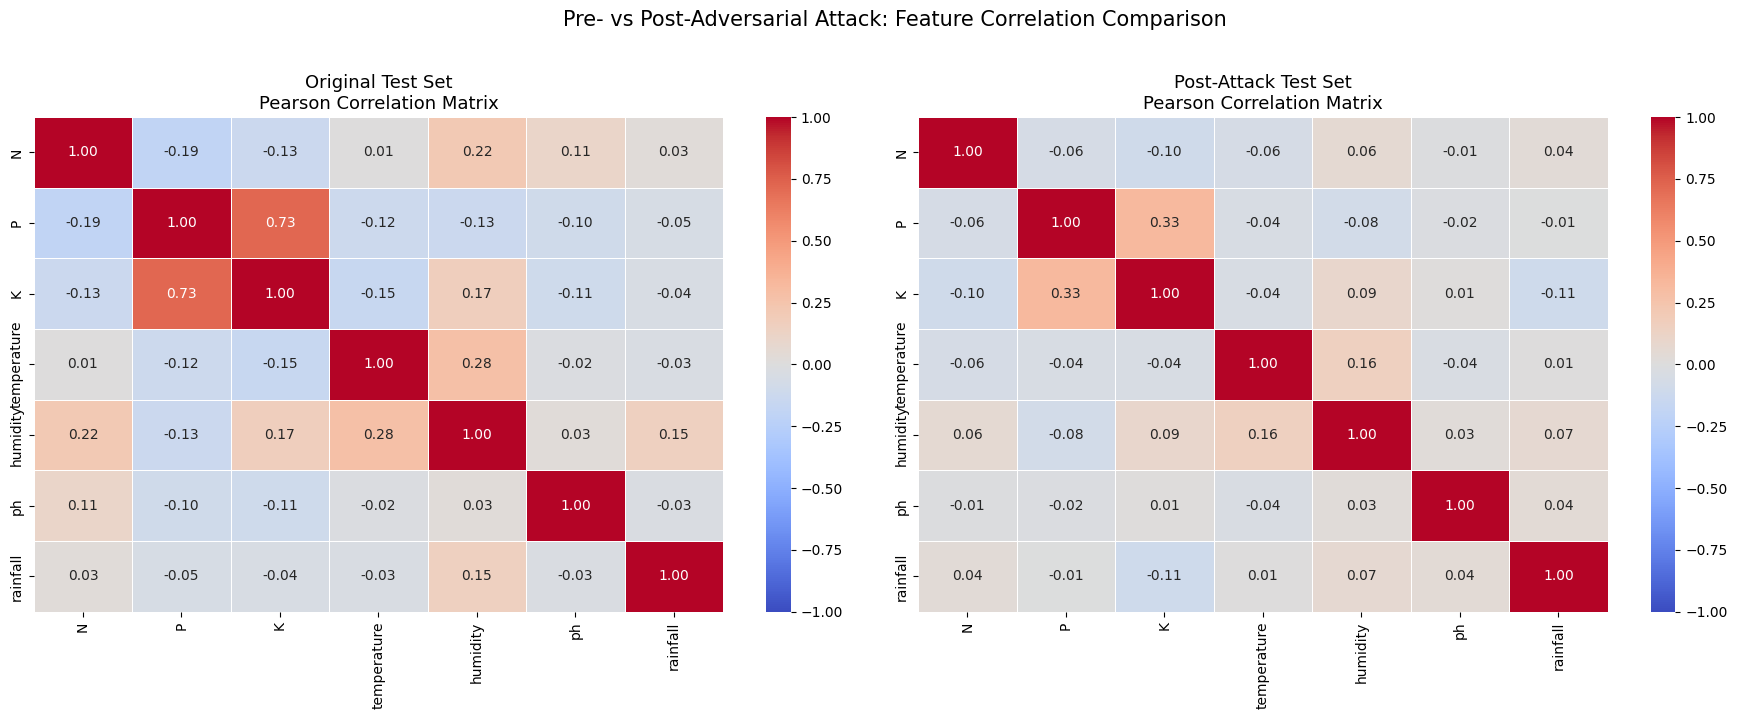

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. Build the adversarially-perturbed test dataset ─────────────────────
# Reconstruct a perturbed copy of X_test by applying each successful attack's
# cumulative deltas to the corresponding features.
X_test_adv = X_test.copy().reset_index(drop=True)

np.random.seed(42)
for _, row in attack_df[attack_df['Success']].iterrows():
    feat_a, feat_b = row['Feature A'], row['Feature B']
    n_iters        = int(row['Iterations'])
    # Replay the random walk for exactly n_iters steps on all test rows
    for _ in range(n_iters):
        X_test_adv[feat_a] += np.random.normal(0, feature_stds[feat_a], size=len(X_test_adv))
        X_test_adv[feat_b] += np.random.normal(0, feature_stds[feat_b], size=len(X_test_adv))

# ── 2. Compute correlation matrices ───────────────────────────────────────
corr_original = X_test[feature_list].corr()
corr_attacked = X_test_adv[feature_list].corr()
corr_delta    = corr_attacked - corr_original

# ── 3. Side-by-side heatmaps ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    corr_original, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, ax=axes[0], linewidths=0.4
)
axes[0].set_title('Original Test Set\nPearson Correlation Matrix', fontsize=13)

sns.heatmap(
    corr_attacked, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, ax=axes[1], linewidths=0.4
)
axes[1].set_title('Post-Attack Test Set\nPearson Correlation Matrix', fontsize=13)

plt.suptitle('Pre- vs Post-Adversarial Attack: Feature Correlation Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
